# 🏠 Boston House Price Prediction
### ShadowFox AIML Internship — Beginner Task

**Goal:** Predict the median value of homes (`MEDV`) using features like crime rate, number of rooms, etc.

---
**Dataset Columns:**
| Column | Description |
|--------|-------------|
| CRIM | Per capita crime rate |
| ZN | Proportion of residential land zoned for large lots |
| INDUS | Proportion of non-retail business acres |
| CHAS | Charles River dummy variable (1 if tract bounds river) |
| NOX | Nitric oxide concentration |
| RM | Average number of rooms per dwelling |
| AGE | Proportion of owner-occupied units built before 1940 |
| DIS | Distances to employment centres |
| RAD | Index of accessibility to radial highways |
| TAX | Property tax rate |
| PTRATIO | Pupil-teacher ratio |
| B | Proportion of Black residents |
| LSTAT | % lower status of the population |
| **MEDV** | **Median house value (TARGET)** |

## Step 1: Import Libraries

In [2]:
# ── Data handling ──
import pandas as pd
import numpy as np

# ── Visualisation ──
import matplotlib.pyplot as plt
import seaborn as sns

# ── Preprocessing ──
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# ── Models ──
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor

# ── Evaluation ──
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

# Make plots look nice
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## Step 2: Load the Dataset

In [3]:
# Load the CSV file
df = pd.read_csv('HousingData.csv')

print('Dataset Shape:', df.shape)
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')
df.head(10)

Dataset Shape: (506, 14)
Rows: 506, Columns: 14


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2
5,0.02985,0.0,2.18,0.0,0.458,6.430,58.7,6.0622,3,222,18.7,394.12,5.21,28.7
6,0.08829,12.5,7.87,NaN,0.524,6.012,66.6,5.5605,5,311,15.2,395.60,12.43,22.9
7,0.14455,12.5,7.87,0.0,0.524,6.172,96.1,5.9505,5,311,15.2,396.90,19.15,27.1
8,0.21124,12.5,7.87,0.0,0.524,5.631,100.0,6.0821,5,311,15.2,386.63,29.93,16.5
9,0.17004,12.5,7.87,NaN,0.524,6.004,85.9,6.5921,5,311,15.2,386.71,17.10,18.9


## Step 3: Exploratory Data Analysis (EDA)

In [4]:
# Basic statistics — understand the data
print('📊 Statistical Summary:')
df.describe().round(2)

📊 Statistical Summary:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,486.00,486.00,486.00,486.00,506.00,506.00,486.00,506.00,506.00,506.00,506.00,506.00,486.00,506.00
mean,3.61,11.21,11.08,0.07,0.55,6.28,68.52,3.80,9.55,408.24,18.46,356.67,12.72,22.53
std,8.72,23.39,6.84,0.26,0.12,0.70,28.00,2.11,8.71,168.54,2.16,91.29,7.16,9.20
min,0.01,0.00,0.46,0.00,0.38,3.56,2.90,1.13,1.00,187.00,12.60,0.32,1.73,5.00
25%,0.08,0.00,5.19,0.00,0.45,5.89,45.18,2.10,4.00,279.00,17.40,375.38,7.12,17.02
50%,0.25,0.00,9.69,0.00,0.54,6.21,76.80,3.21,5.00,330.00,19.05,391.44,11.43,21.20
75%,3.56,12.50,18.10,0.00,0.62,6.62,93.98,5.19,24.00,666.00,20.20,396.22,16.96,25.00
max,88.98,100.00,27.74,1.00,0.87,8.78,100.00,12.13,24.00,711.00,22.00,396.90,37.97,50.00


In [5]:
# Check for missing values
print('🔍 Missing Values:')
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct.round(2)})
print(missing_df[missing_df['Missing Count'] > 0])

🔍 Missing Values:
       Missing Count  Missing %
CRIM              20       3.95
ZN                20       3.95
INDUS             20       3.95
CHAS              20       3.95
AGE               20       3.95
LSTAT             20       3.95


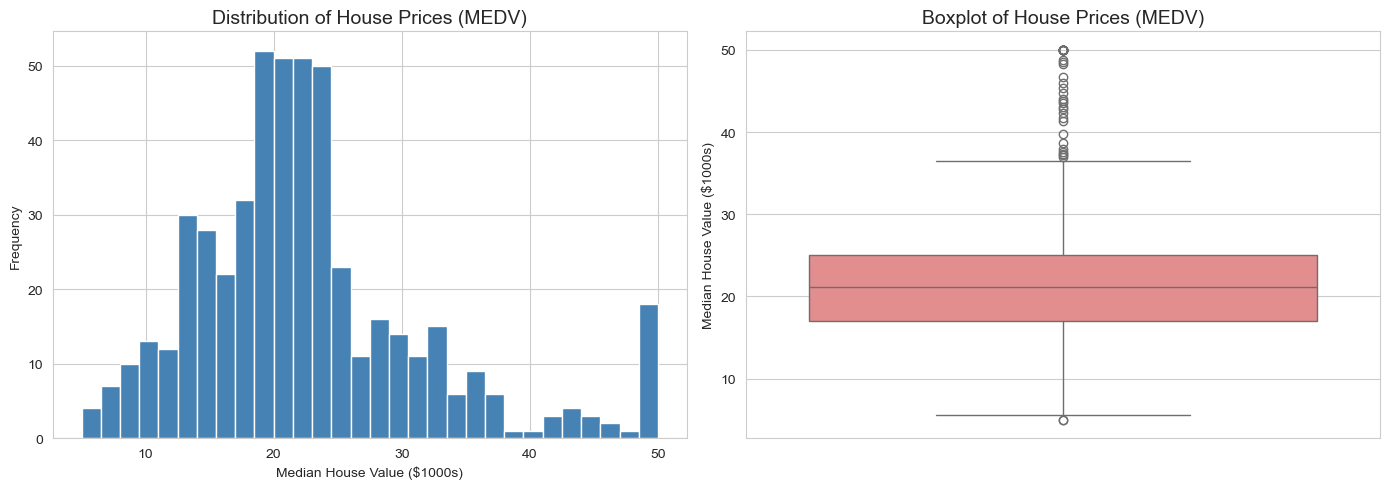

Average house price: $22.5k | Range: $5.0k – $50.0k


In [6]:
# Distribution of target variable (MEDV = House Price)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['MEDV'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of House Prices (MEDV)', fontsize=14)
axes[0].set_xlabel('Median House Value ($1000s)')
axes[0].set_ylabel('Frequency')

sns.boxplot(y=df['MEDV'], ax=axes[1], color='lightcoral')
axes[1].set_title('Boxplot of House Prices (MEDV)', fontsize=14)
axes[1].set_ylabel('Median House Value ($1000s)')

plt.tight_layout()
plt.show()
print(f'Average house price: ${df["MEDV"].mean():.1f}k | Range: ${df["MEDV"].min()}k – ${df["MEDV"].max()}k')

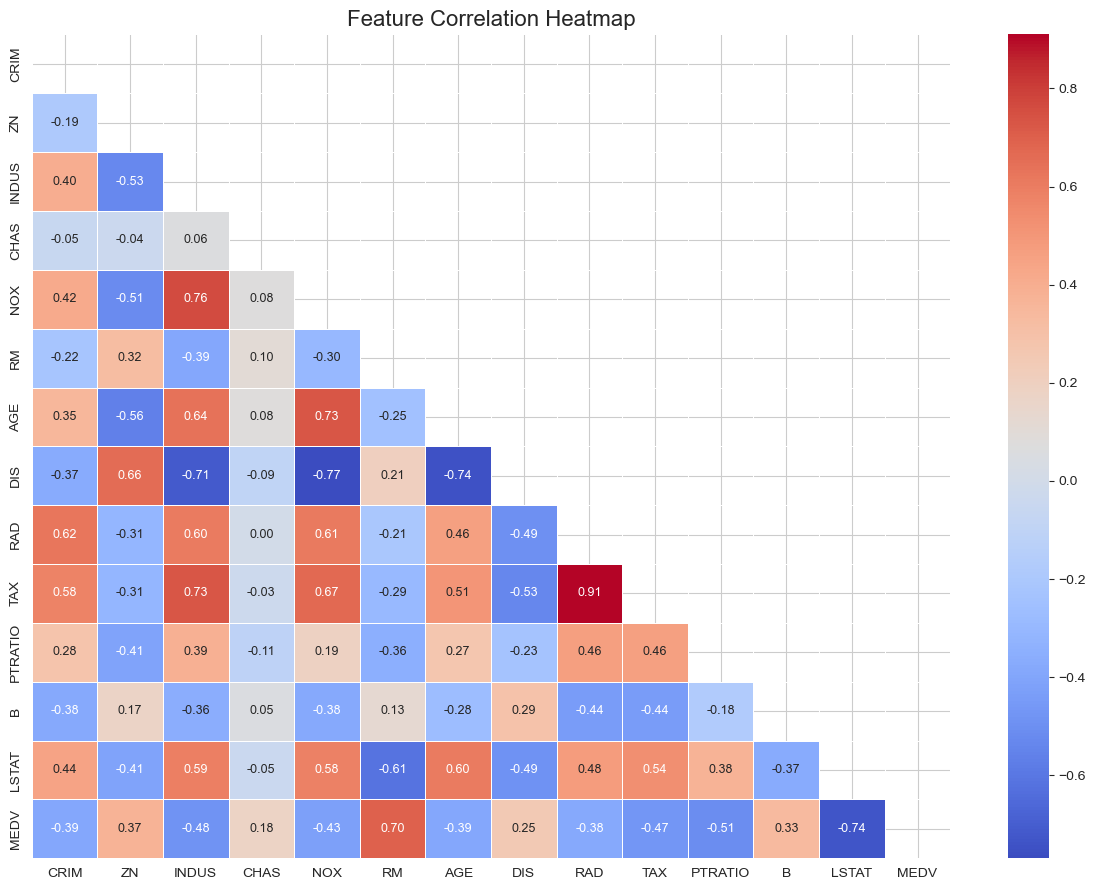


🎯 Correlation with House Price (MEDV):
MEDV       1.000000
RM         0.695360
ZN         0.373136
B          0.333461
DIS        0.249929
CHAS       0.181391
RAD       -0.381626
CRIM      -0.391363
AGE       -0.394656
NOX       -0.427321
TAX       -0.468536
INDUS     -0.481772
PTRATIO   -0.507787
LSTAT     -0.735822


In [7]:
# Correlation heatmap — see which features affect price the most
plt.figure(figsize=(12, 9))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, annot_kws={'size': 9})
plt.title('Feature Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

# Print top correlations with MEDV
print('\n🎯 Correlation with House Price (MEDV):')
print(corr_matrix['MEDV'].sort_values(ascending=False).to_string())

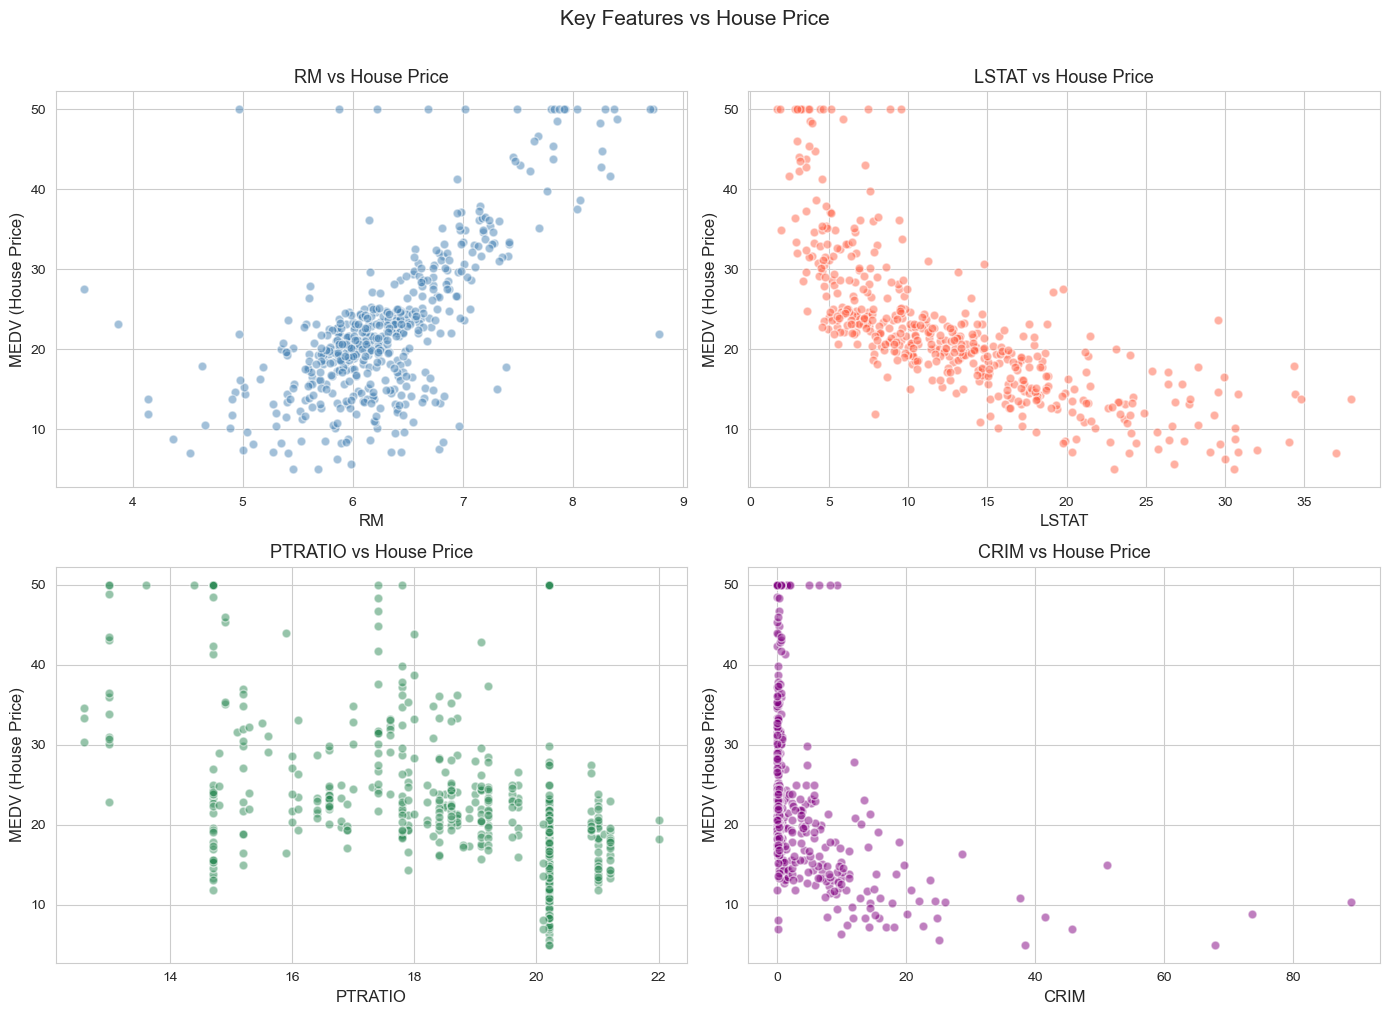

In [8]:
# Scatter plots: top features vs house price
top_features = ['RM', 'LSTAT', 'PTRATIO', 'CRIM']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colors = ['steelblue', 'tomato', 'seagreen', 'purple']
for i, feat in enumerate(top_features):
    axes[i].scatter(df[feat], df['MEDV'], alpha=0.5, color=colors[i], edgecolor='white', s=40)
    axes[i].set_xlabel(feat, fontsize=12)
    axes[i].set_ylabel('MEDV (House Price)', fontsize=12)
    axes[i].set_title(f'{feat} vs House Price', fontsize=13)

plt.suptitle('Key Features vs House Price', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

## Step 4: Data Preprocessing

In [9]:
# ── 4a. Handle Missing Values ──
# We fill missing values with the median of each column
# (Median is better than mean when there are outliers)
imputer = SimpleImputer(strategy='median')
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

print('Missing values after imputation:')
print(df_imputed.isnull().sum().sum(), '← should be 0')

Missing values after imputation:
0 ← should be 0


In [10]:
# ── 4b. Remove Outliers using IQR Technique ──
# (As shown in the task overview slides)
def remove_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return dataframe[(dataframe[column] >= lower) & (dataframe[column] <= upper)]

# Apply only on the target column (MEDV) to remove extreme price outliers
df_clean = remove_outliers_iqr(df_imputed, 'MEDV')
print(f'Rows before outlier removal: {len(df_imputed)}')
print(f'Rows after  outlier removal: {len(df_clean)}')
print(f'Removed {len(df_imputed) - len(df_clean)} outlier rows')

Rows before outlier removal: 506
Rows after  outlier removal: 466
Removed 40 outlier rows


In [11]:
# ── 4c. Split Features (X) and Target (y) ──
X = df_clean.drop('MEDV', axis=1)   # All columns except house price
y = df_clean['MEDV']                # House price (what we want to predict)

print('Feature matrix X shape:', X.shape)
print('Target vector y shape: ', y.shape)
print('\nFeatures used:', list(X.columns))

Feature matrix X shape: (466, 13)
Target vector y shape:  (466,)

Features used: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']


In [12]:
# ── 4d. Train-Test Split ──
# 80% data for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training samples:  {X_train.shape[0]}')
print(f'Testing  samples:  {X_test.shape[0]}')

Training samples:  372
Testing  samples:  94


In [13]:
# ── 4e. Feature Scaling ──
# StandardScaler brings all features to the same scale
# (Important so that features with large values don't dominate)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # Fit on train, transform train
X_test_scaled  = scaler.transform(X_test)        # Only transform test (no fitting!)

print('✅ Data is scaled and ready for model training!')

✅ Data is scaled and ready for model training!


## Step 5: Model Training & Comparison

In [14]:
# We'll train 4 different models and compare them
models = {
    'Linear Regression':       LinearRegression(),
    'Decision Tree':           DecisionTreeRegressor(random_state=42),
    'Random Forest':           RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting':       GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = []

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)
    
    # Predict
    y_pred = model.predict(X_test_scaled)
    
    # Evaluate
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    
    results.append({'Model': name, 'RMSE': round(rmse,3), 'MAE': round(mae,3), 'R² Score': round(r2,4)})
    print(f'✅ {name:<25} | RMSE: {rmse:.3f} | MAE: {mae:.3f} | R²: {r2:.4f}')

results_df = pd.DataFrame(results).sort_values('R² Score', ascending=False).reset_index(drop=True)
print('\n🏆 Model Comparison:')
results_df

✅ Linear Regression         | RMSE: 3.223 | MAE: 2.277 | R²: 0.7411
✅ Decision Tree             | RMSE: 3.859 | MAE: 2.838 | R²: 0.6288
✅ Random Forest             | RMSE: 2.598 | MAE: 1.953 | R²: 0.8318
✅ Gradient Boosting         | RMSE: 2.450 | MAE: 1.882 | R²: 0.8504

🏆 Model Comparison:


,Model,RMSE,MAE,R² Score
0,Gradient Boosting,2.450,1.882,0.8504
1,Random Forest,2.598,1.953,0.8318
2,Linear Regression,3.223,2.277,0.7411
3,Decision Tree,3.859,2.838,0.6288


## Step 6: Best Model — Gradient Boosting

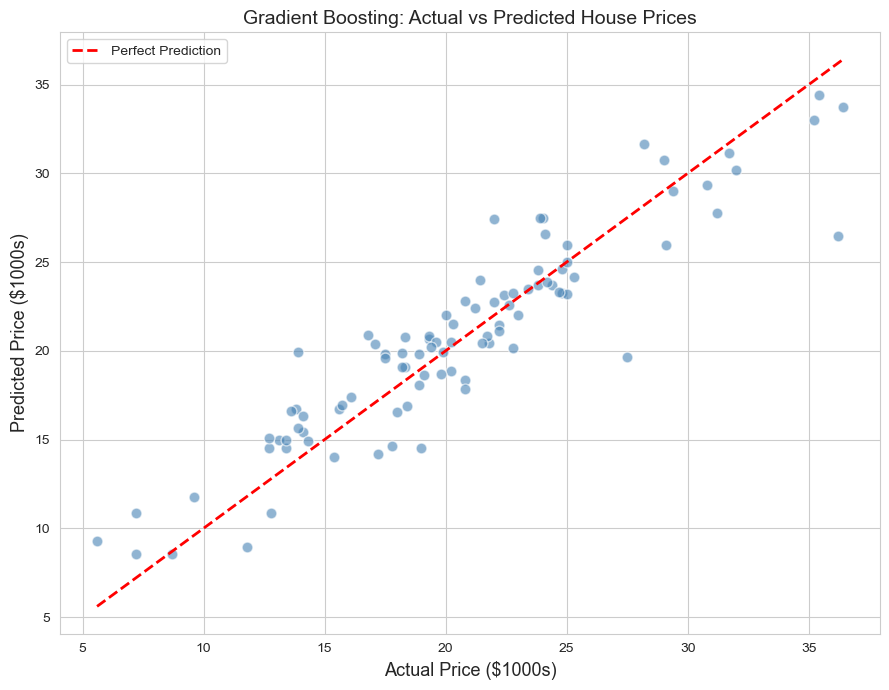

In [15]:
# Gradient Boosting usually wins — let's use it as our final model
best_model = models['Gradient Boosting']
y_pred_best = best_model.predict(X_test_scaled)

# ── Plot: Actual vs Predicted ──
plt.figure(figsize=(9, 7))
plt.scatter(y_test, y_pred_best, alpha=0.6, color='steelblue', edgecolor='white', s=60)
# Perfect prediction line
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
plt.plot(lims, lims, 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Price ($1000s)', fontsize=13)
plt.ylabel('Predicted Price ($1000s)', fontsize=13)
plt.title('Gradient Boosting: Actual vs Predicted House Prices', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

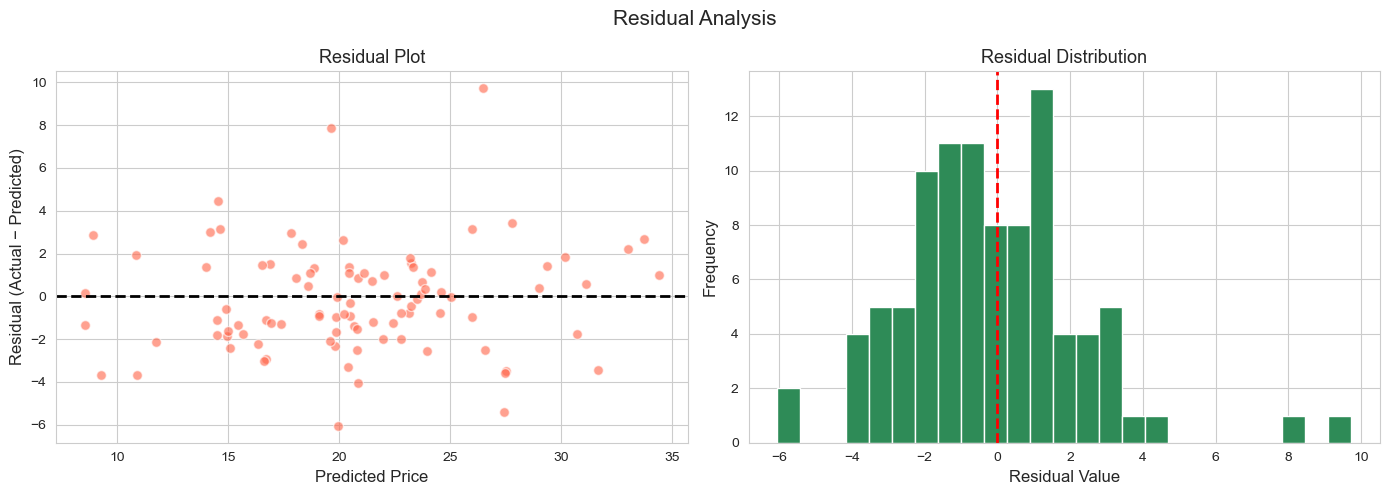

In [16]:
# ── Plot: Residuals ──
# Residual = Actual - Predicted (should be close to 0 for a good model)
residuals = y_test - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_best, residuals, alpha=0.6, color='tomato', edgecolor='white', s=50)
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=2)
axes[0].set_xlabel('Predicted Price', fontsize=12)
axes[0].set_ylabel('Residual (Actual − Predicted)', fontsize=12)
axes[0].set_title('Residual Plot', fontsize=13)

axes[1].hist(residuals, bins=25, color='seagreen', edgecolor='white')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residual Value', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Residual Distribution', fontsize=13)

plt.suptitle('Residual Analysis', fontsize=15)
plt.tight_layout()
plt.show()

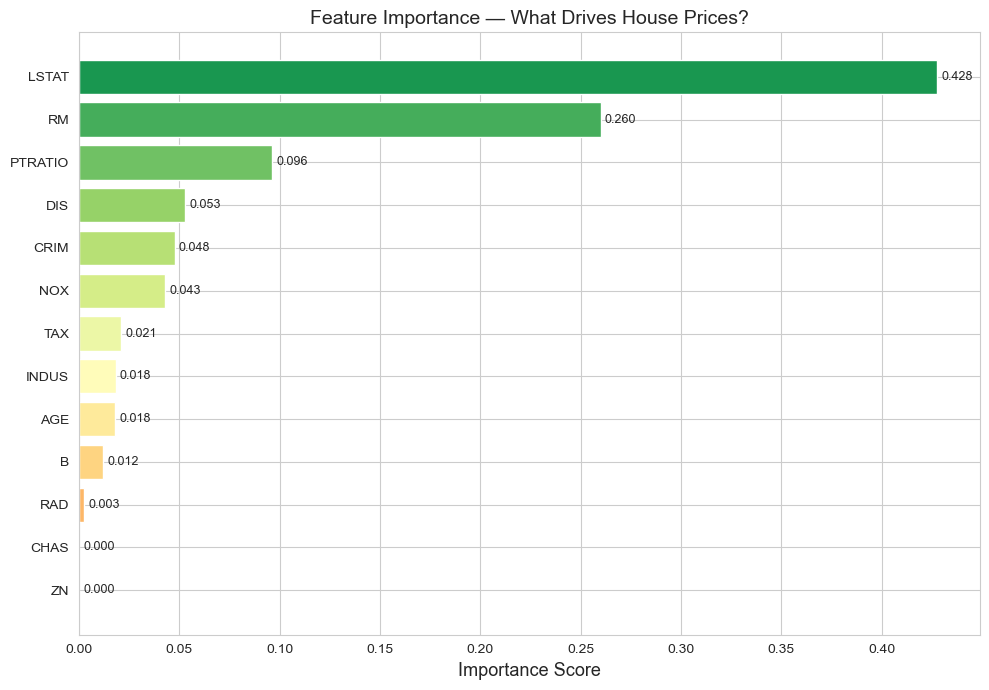

In [17]:
# ── Feature Importance: Which factors affect price most? ──
feat_importance = pd.Series(
    best_model.feature_importances_, index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(feat_importance)))
bars = plt.barh(feat_importance.index, feat_importance.values, color=colors, edgecolor='white')
plt.xlabel('Importance Score', fontsize=13)
plt.title('Feature Importance — What Drives House Prices?', fontsize=14)
for bar, val in zip(bars, feat_importance.values):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## Step 7: Model Evaluation Summary

In [18]:
# Final metrics for the best model
mse  = mean_squared_error(y_test, y_pred_best)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred_best)
r2   = r2_score(y_test, y_pred_best)

print('='*50)
print('   🏆 FINAL MODEL: Gradient Boosting Regressor')
print('='*50)
print(f'   MSE  (Mean Squared Error)     : {mse:.3f}')
print(f'   RMSE (Root Mean Sq Error)     : {rmse:.3f}  ← avg error in $1000s')
print(f'   MAE  (Mean Absolute Error)    : {mae:.3f}')
print(f'   R²   (Variance Explained)     : {r2:.4f}  ← {r2*100:.1f}% accuracy')
print('='*50)
print(f'\n💡 Interpretation:')
print(f'   On average, our model predicts house prices')
print(f'   within ±${rmse:.1f}k of the actual value.')
print(f'   The model explains {r2*100:.1f}% of price variation.')

   🏆 FINAL MODEL: Gradient Boosting Regressor
   MSE  (Mean Squared Error)     : 6.003
   RMSE (Root Mean Sq Error)     : 2.450  ← avg error in $1000s
   MAE  (Mean Absolute Error)    : 1.882
   R²   (Variance Explained)     : 0.8504  ← 85.0% accuracy

💡 Interpretation:
   On average, our model predicts house prices
   within ±$2.5k of the actual value.
   The model explains 85.0% of price variation.


## Step 8: Predict a New House Price

In [19]:
# Try predicting the price of a new house!
# Enter values for each feature below:
new_house = pd.DataFrame([{
    'CRIM':    0.05,   # Low crime area
    'ZN':      20.0,   # Some residential zoning
    'INDUS':   5.0,    # Moderate industrial
    'CHAS':    0,      # Not near Charles River
    'NOX':     0.45,   # Low pollution
    'RM':      7.0,    # 7 rooms on average
    'AGE':     40.0,   # Relatively newer
    'DIS':     4.5,    # Moderate distance to jobs
    'RAD':     3,      # Good highway access
    'TAX':     250,    # Moderate taxes
    'PTRATIO': 15.0,   # Good school ratio
    'B':       390.0,
    'LSTAT':   5.0     # Low % lower status
}])

# Scale the input the same way we scaled training data
new_house_scaled = scaler.transform(new_house)

# Predict!
predicted_price = best_model.predict(new_house_scaled)[0]
print(f'🏡 Predicted House Price: ${predicted_price:.1f}k  (i.e., ${predicted_price*1000:,.0f})')

🏡 Predicted House Price: $33.2k  (i.e., $33,232)


## ✅ Summary

| Step | What we did |
|------|-------------|
| 1 | Imported libraries |
| 2 | Loaded the Boston Housing dataset |
| 3 | Explored data with statistics and visualizations |
| 4 | Handled missing values, outliers, scaling, and train-test split |
| 5 | Trained 4 models and compared them |
| 6 | Selected best model (Gradient Boosting) and analyzed results |
| 7 | Evaluated using RMSE, MAE, and R² |
| 8 | Used model to predict price of a new house |

**Key Insight:** `LSTAT` (lower status %) and `RM` (rooms) are the strongest predictors of house price.